# Instruction Tuning Small Language Models for Survey Response Generation

# Instruction Tuning for Survey Response Generation
*This notebook was automatically generated from multiple markdown files.*

**Purpose**: Instruction-tuning small language models on a custom dataset for generating synthetic survey responses.

**Contents**:
1. Setup and Hardware Checks
2. Data Processing
3. Model Training (with LoRA/QLoRA)
4. Evaluation
5. Hugging Face Integration
6. Inference Demo


---

# Setup


# PersonaVerse

## Instruction Tuning Small Language Models for Survey Response Generation

Implementing end-to-end solution for instruction-tuning small language models on a custom dataset for synthetic survey questionnaire response generation. The implementation follows best practices and results in models that can be used via the Hugging Face inference API.

## Overview

1. **Setup and Hardware Checks**: Check available resources and install dependencies
2. **Data Processing**: Load and prepare the ChatML dataset for instruction tuning
3. **Model Training**: Implement parameter-efficient fine-tuning with TinyLlama (and optionally other models)
4. **Evaluation**: Assess model performance with standard and domain-specific metrics
5. **Hugging Face Integration**: Push the model to HF Hub and setup inference
6. **Inference Demo**: Test the fine-tuned model on sample inputs

## 1. Setup and Hardware Checks


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
# change to working directory
os.chdir('/content/drive/MyDrive/PersonaVerse')
# check if correct
!ls -la

total 1139
drwx------ 2 root root   4096 Apr  7 14:32  data
-rw------- 1 root root 579096 Apr  7 16:37 'instruction_tuning_notebook (1).ipynb'
-rw------- 1 root root 578035 Apr 10 02:52  instruction_tuning_notebook.ipynb
drwx------ 2 root root   4096 Apr  7 14:39  results


In [3]:
# Check for GPU availability
import torch
import psutil
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import logging
from tqdm.auto import tqdm
from datetime import datetime

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

# Check GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    logger.info(f"Using GPU: {torch.cuda.get_device_name(0)}")
    logger.info(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    logger.info(f"Available GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    logger.warning("No GPU available, using CPU. Training will be extremely slow.")

# Check RAM
ram_gb = psutil.virtual_memory().total / 1e9
logger.info(f"Total RAM: {ram_gb:.2f} GB")

# Determine if we're running on Colab
IN_COLAB = 'google.colab' in sys.modules
logger.info(f"Running in Google Colab: {IN_COLAB}")

# Set environment variables for better performance
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid warnings


In [4]:
# Install required packages
!pip install -q transformers datasets accelerate bitsandbytes peft evaluate rouge_score py7zr sentencepiece
!pip install -q nltk bert_score wandb trl


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━

In [28]:
# Create resource-adaptive configuration based on available hardware
class Config:
    def __init__(self):
        # Basic configuration
        self.seed = 42
        self.base_model = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # Default model
        self.experiment_name = f"survey-finetuned-{self.base_model.split('/')[-1]}"

        # Determine batch size and other parameters based on available resources
        if torch.cuda.is_available():
            gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
            if gpu_mem > 30:  # A100 or similar
                self.batch_size = 8
                self.gradient_accumulation_steps = 1
                self.use_4bit = False
                self.use_8bit = True
            elif gpu_mem > 12:  # RTX 3090 or similar
                self.batch_size = 4
                self.gradient_accumulation_steps = 2
                self.use_4bit = True
                self.use_8bit = False
            else:  # RTX 2080Ti or similar
                self.batch_size = 2
                self.gradient_accumulation_steps = 4
                self.use_4bit = True
                self.use_8bit = False
        else:  # CPU only
            self.batch_size = 1
            self.gradient_accumulation_steps = 8
            self.use_4bit = True
            self.use_8bit = False

        # Training configuration
        self.num_train_epochs = 5
        self.learning_rate = 2e-4
        self.lr_scheduler_type = "cosine"
        self.warmup_ratio = 0.03
        self.weight_decay = 0.001
        self.max_grad_norm = 0.3

        # LoRA configuration
        self.lora_r = 16
        self.lora_alpha = 32
        self.lora_dropout = 0.05

        # Data configuration
        self.max_seq_length = 1024  # Can be adjusted based on available memory
        self.dataset_path = "./data"  # Path to the dataset

        # Saving and evaluation
        self.save_steps = 100
        self.eval_steps = 100
        self.logging_steps = 10
        self.output_dir = f"./results/{self.experiment_name}"

        # Alternative models to try
        self.alternative_models = [
            "microsoft/phi-2"
            #"mistralai/Mistral-7B-v0.1"
        ]

    def update_for_model(self, model_name):
        """Update configuration for a specific model"""
        self.base_model = model_name
        self.experiment_name = f"survey-finetuned-{model_name.split('/')[-1]}"
        self.output_dir = f"./results/{self.experiment_name}"

        # Adjust parameters based on model size
        if "1.1B" in model_name or "phi-2" in model_name:
            # Small models
            self.batch_size = min(self.batch_size * 2, 8)
        elif "7B" in model_name:
            # Medium models
            self.batch_size = max(1, self.batch_size // 2)
            self.gradient_accumulation_steps *= 2
            self.use_4bit = True

        return self

# Initialize configuration
config = Config()
print(f"Configured for:\n- Model: {config.base_model}\n- Batch size: {config.batch_size}\n- Gradient accumulation steps: {config.gradient_accumulation_steps}")


Configured for:
- Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
- Batch size: 8
- Gradient accumulation steps: 1


---

# Data_Processing


Time to implement the data processing pipeline to:
1. Load the JSON dataset in ChatML format
2. Process it into the appropriate format for instruction tuning
3. Handle tokenization efficiently

In [29]:
# Create data directory if it doesn't exist
Path(config.dataset_path).mkdir(parents=True, exist_ok=True)

# Check if the dataset is already available
train_path = Path(config.dataset_path) / "train.json"
validation_path = Path(config.dataset_path) / "validation.json"
test_path = Path(config.dataset_path) / "test.json"

if not all(p.exists() for p in [train_path, validation_path, test_path]):
    logger.warning("Dataset files not found. Please upload or provide the files.")
    logger.info("Expected files: train.json, validation.json, test.json in the ./data/ directory")

    if IN_COLAB:
        from google.colab import files
        logger.info("Running in Colab. Please upload your dataset files.")
        uploaded = files.upload()

        # Move uploaded files to the data directory
        for filename in uploaded.keys():
            if filename in ["train.json", "validation.json", "test.json"]:
                with open(Path(config.dataset_path) / filename, 'wb') as f:
                    f.write(uploaded[filename])
                logger.info(f"Saved {filename} to {config.dataset_path}")



Sample 1:
ID: 000002
Domain: healthcare
Persona: A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare
Question: How often was your pain well controlled during this hospital stay?
Response length: 448

Sample 2:
ID: 000003
Domain: healthcare
Persona: A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare
Question: How often did you get help as soon as you wanted after you pressed the call button?
Response length: 584

Sample 3:
ID: 000004
Domain: healthcare
Persona: A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare
Question: Before giving you any new medicine, how often did hospital staff describe possible side effects in a way you could understand?
Response length: 668

Sample 4:
ID: 000005
Domain: healthcare
Persona: A nurse who educates the child about modern medical treatments and encourages a balanced appr

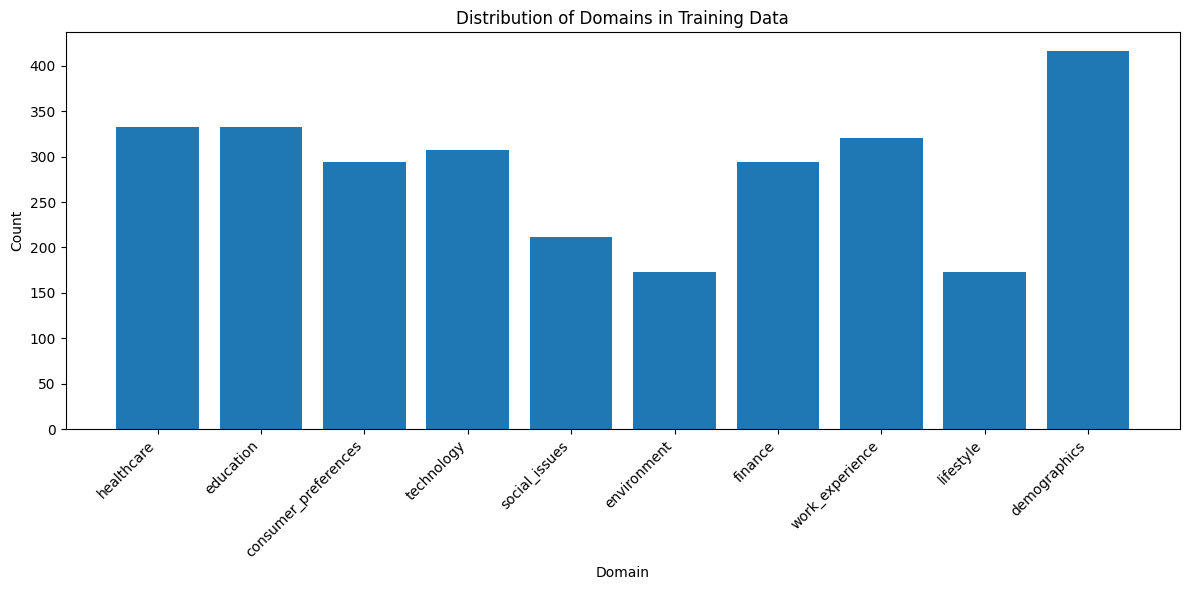

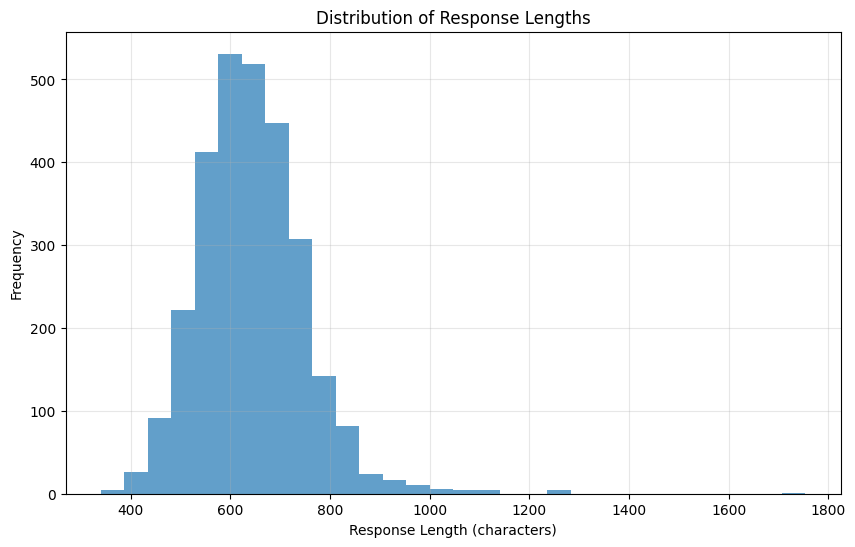

In [30]:
# Function to load the dataset from JSON files
def load_chatml_dataset(file_path):
    """Load dataset from a JSON file in ChatML format"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return data
    except json.JSONDecodeError:
        # Try loading line by line if the file is not a single JSON object
        data = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    data.append(json.loads(line.strip()))
                except json.JSONDecodeError:
                    continue
        return data
    except Exception as e:
        logger.error(f"Error loading dataset from {file_path}: {e}")
        return []

# Data exploration and visualization function
def explore_dataset(dataset_path, sample_size=5):
    """Explore and visualize the dataset"""
    # Load all three splits
    train_data = load_chatml_dataset(Path(dataset_path) / "train.json")
    val_data = load_chatml_dataset(Path(dataset_path) / "validation.json")
    test_data = load_chatml_dataset(Path(dataset_path) / "test.json")

    # Display dataset statistics
    logger.info(f"Dataset statistics:")
    logger.info(f"- Train samples: {len(train_data)}")
    logger.info(f"- Validation samples: {len(val_data)}")
    logger.info(f"- Test samples: {len(test_data)}")

    # Extract domains
    all_domains = set()
    for split in [train_data, val_data, test_data]:
        for sample in split:
            if "domain" in sample:
                all_domains.add(sample["domain"])

    logger.info(f"- Unique domains: {len(all_domains)}")
    logger.info(f"- Domains: {', '.join(sorted(all_domains))}")

    # Show sample data
    logger.info(f"\nSample from training data:")
    for i, sample in enumerate(train_data[:sample_size]):
        print(f"\nSample {i+1}:")
        print(f"ID: {sample.get('id', 'N/A')}")
        print(f"Domain: {sample.get('domain', 'N/A')}")
        print(f"Persona: {sample.get('persona', 'N/A')}")
        print(f"Question: {sample.get('question', 'N/A')}")
        print(f"Response length: {sample.get('response_length', 'N/A')}")

    # Visualize distribution of domains
    domain_counts = {}
    for sample in train_data:
        domain = sample.get('domain', 'unknown')
        domain_counts[domain] = domain_counts.get(domain, 0) + 1

    plt.figure(figsize=(12, 6))
    plt.bar(domain_counts.keys(), domain_counts.values())
    plt.title('Distribution of Domains in Training Data')
    plt.xlabel('Domain')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Visualize response length distribution
    response_lengths = [sample.get('response_length', 0) for sample in train_data if 'response_length' in sample]

    plt.figure(figsize=(10, 6))
    plt.hist(response_lengths, bins=30, alpha=0.7)
    plt.title('Distribution of Response Lengths')
    plt.xlabel('Response Length (characters)')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "train": train_data,
        "validation": val_data,
        "test": test_data,
        "domains": sorted(all_domains)
    }

# Explore the dataset
try:
    dataset_info = explore_dataset(config.dataset_path)
except FileNotFoundError:
    logger.warning("Dataset files not found. Please upload the files before proceeding.")


In [31]:
from transformers import AutoTokenizer
from datasets import Dataset

# Function to format data for instruction tuning
def format_instruction_data(samples, tokenizer):
    """Format data in the appropriate format for instruction tuning"""
    formatted_data = []

    for sample in samples:
        # Extract fields
        system_prompt = sample.get("system_prompt", "")
        user_prompt = sample.get("user_prompt", "")
        response = sample.get("response", "")

        # Create the formatted example based on the model's chat template
        if hasattr(tokenizer, "apply_chat_template"):
            # Use the model's chat template if available
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ]
            input_text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            # For training, include the expected response
            full_text = tokenizer.apply_chat_template(
                messages + [{"role": "assistant", "content": response}],
                tokenize=False
            )
        else:
            # Fallback format if chat template is not available
            input_text = f"System: {system_prompt}\nUser: {user_prompt}\nAssistant:"
            full_text = f"System: {system_prompt}\nUser: {user_prompt}\nAssistant: {response}"

        formatted_data.append({
            "id": sample.get("id", ""),
            "domain": sample.get("domain", ""),
            "persona": sample.get("persona", ""),
            "question": sample.get("question", ""),
            "input": input_text,
            "output": response,
            "full_text": full_text
        })

    return formatted_data

# Tokenization function for preparing dataset
def tokenize_function(examples, tokenizer, max_length):
    """Tokenize the dataset examples for training"""
    # Tokenize inputs separately (for input-only inference)
    model_inputs = tokenizer(examples["input"], truncation=True, max_length=max_length)

    # Tokenize full text (input + expected output)
    full_text_tokenized = tokenizer(examples["full_text"], truncation=True, max_length=max_length)

    # Set input_ids and attention_mask from full text for training
    model_inputs["input_ids"] = full_text_tokenized["input_ids"]
    model_inputs["attention_mask"] = full_text_tokenized["attention_mask"]

    # Create labels for training (same as input_ids for causal LM)
    model_inputs["labels"] = model_inputs["input_ids"].copy()

    return model_inputs

# Prepare the dataset for training
def prepare_dataset_for_training(config):
    """Prepare the full dataset for training"""
    logger.info("Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(
        config.base_model,
        padding_side="right",
        trust_remote_code=True
    )

    # Add pad token if not present
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Load raw data
    logger.info("Loading and processing dataset...")
    train_data = load_chatml_dataset(Path(config.dataset_path) / "train.json")
    val_data = load_chatml_dataset(Path(config.dataset_path) / "validation.json")
    test_data = load_chatml_dataset(Path(config.dataset_path) / "test.json")

    # Format data for instruction tuning
    train_formatted = format_instruction_data(train_data, tokenizer)
    val_formatted = format_instruction_data(val_data, tokenizer)
    test_formatted = format_instruction_data(test_data, tokenizer)

    # Convert to Datasets
    train_dataset = Dataset.from_list(train_formatted)
    val_dataset = Dataset.from_list(val_formatted)
    test_dataset = Dataset.from_list(test_formatted)

    # Apply tokenization
    train_tokenized = train_dataset.map(
        lambda examples: tokenize_function(examples, tokenizer, config.max_seq_length),
        batched=True,
        remove_columns=train_dataset.column_names
    )

    val_tokenized = val_dataset.map(
        lambda examples: tokenize_function(examples, tokenizer, config.max_seq_length),
        batched=True,
        remove_columns=val_dataset.column_names
    )

    test_tokenized = test_dataset.map(
        lambda examples: tokenize_function(examples, tokenizer, config.max_seq_length),
        batched=True,
        remove_columns=test_dataset.column_names
    )

    logger.info(f"Dataset preparation complete!")
    logger.info(f"Train samples: {len(train_tokenized)}")
    logger.info(f"Validation samples: {len(val_tokenized)}")
    logger.info(f"Test samples: {len(test_tokenized)}")

    return {
        "train": train_tokenized,
        "validation": val_tokenized,
        "test": test_tokenized,
        "train_raw": train_formatted,
        "val_raw": val_formatted,
        "test_raw": test_formatted,
        "tokenizer": tokenizer
    }

# Optional: Data augmentation techniques
def augment_data(dataset, domains=None, augmentation_factor=0.2):
    """Apply data augmentation to increase diversity (optional)"""
    # This is a simple implementation - could be extended with more sophisticated techniques
    augmented_data = []
    base_samples = dataset["train_raw"]

    # If domains is specified, focus on underrepresented domains
    if domains:
        domain_counts = {}
        for sample in base_samples:
            domain = sample.get("domain", "unknown")
            domain_counts[domain] = domain_counts.get(domain, 0) + 1

        # Find underrepresented domains
        avg_count = sum(domain_counts.values()) / len(domain_counts)
        underrepresented = [d for d, count in domain_counts.items() if count < avg_count]

        # Filter samples from underrepresented domains
        candidates = [s for s in base_samples if s.get("domain", "") in underrepresented]
    else:
        candidates = base_samples

    # Simple augmentation: remix personas and questions from the same domain
    num_to_augment = int(len(base_samples) * augmentation_factor)

    # Group by domain
    domain_samples = {}
    for sample in candidates:
        domain = sample.get("domain", "unknown")
        if domain not in domain_samples:
            domain_samples[domain] = []
        domain_samples[domain].append(sample)

    # Create augmented samples
    for _ in range(min(num_to_augment, len(candidates))):
        # Select a random domain that has at least 2 samples
        valid_domains = [d for d, samples in domain_samples.items() if len(samples) >= 2]
        if not valid_domains:
            break

        domain = np.random.choice(valid_domains)
        samples = domain_samples[domain]

        # Pick two different samples
        i, j = np.random.choice(len(samples), 2, replace=False)
        sample1, sample2 = samples[i], samples[j]

        # Create a new sample by mixing elements
        new_sample = sample1.copy()
        new_sample["id"] = f"aug_{sample1.get('id', 'unknown')}"
        new_sample["persona"] = sample2.get("persona", "")
        new_sample["system_prompt"] = sample2.get("system_prompt", "").replace(
            sample2.get("persona", ""), sample1.get("persona", "")
        )

        augmented_data.append(new_sample)

    logger.info(f"Created {len(augmented_data)} augmented samples")
    return augmented_data

# Test the data preparation pipeline
if "dataset_info" in locals():
    logger.info("Preparing dataset for training...")
    processed_dataset = prepare_dataset_for_training(config)

    # Optional: Apply data augmentation
    # augmented_samples = augment_data(processed_dataset)

    logger.info("Dataset preparation complete!")

Map:   0%|          | 0/2854 [00:00<?, ? examples/s]

Map:   0%|          | 0/357 [00:00<?, ? examples/s]

Map:   0%|          | 0/357 [00:00<?, ? examples/s]

---

# Model_Training


Implementing parameter-efficient fine-tuning (LoRA/QLoRA) for our language models:

1. Setting up PEFT (Parameter-Efficient Fine-Tuning) configuration
2. Implementing quantization for memory efficiency
3. Adding support for different model types
4. Creating the training and evaluation pipeline

In [32]:
from transformers import (
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    TrainerCallback,
    BitsAndBytesConfig
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel
)
import bitsandbytes as bnb
import torch.nn as nn
import gc
import os
from huggingface_hub import HfFolder

# Set up torch to use deterministic algorithms for reproducibility
torch.use_deterministic_algorithms(True, warn_only=True)
torch.manual_seed(config.seed)
np.random.seed(config.seed)

# Define a progress tracking callback
class ProgressCallback(TrainerCallback):
    def __init__(self, total_steps):
        self.total_steps = total_steps
        self.completed_steps = 0
        self.start_time = time.time()

    def on_step_end(self, args, state, control, **kwargs):
        self.completed_steps += 1
        if self.completed_steps % 10 == 0:
            elapsed_time = time.time() - self.start_time
            steps_per_second = self.completed_steps / elapsed_time
            remaining_steps = self.total_steps - self.completed_steps
            estimated_time_remaining = remaining_steps / steps_per_second if steps_per_second > 0 else 0

            hours, remainder = divmod(estimated_time_remaining, 3600)
            minutes, seconds = divmod(remainder, 60)

            logger.info(f"Progress: {self.completed_steps}/{self.total_steps} steps " +
                       f"({100 * self.completed_steps / self.total_steps:.2f}%) - " +
                       f"Estimated time remaining: {int(hours)}h {int(minutes)}m {int(seconds)}s")

# Function to free up memory
def free_memory():
    """Free up GPU memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Function to load model with optimizations for memory efficiency
def load_model_for_training(config):
    """Load model with appropriate quantization and optimization settings"""
    logger.info(f"Loading model: {config.base_model}")

    # Set quantization configuration based on available resources
    quantization_config = None
    if config.use_4bit:
        logger.info("Using 4-bit quantization")
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )
    elif config.use_8bit:
        logger.info("Using 8-bit quantization")
        quantization_config = BitsAndBytesConfig(
            load_in_8bit=True
        )

    # Load model with quantization config
    model = AutoModelForCausalLM.from_pretrained(
        config.base_model,
        quantization_config=quantization_config,
        device_map="auto",
        trust_remote_code=True
    )

    # Prepare model for k-bit training if quantization is used
    if config.use_4bit or config.use_8bit:
        model = prepare_model_for_kbit_training(model)

    # Get model architecture type to configure LoRA appropriately
    model_type = model.config.model_type.lower()

    # Define target modules based on model architecture
    if "llama" in model_type:
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    elif "mistral" in model_type:
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    elif "gpt" in model_type:
        target_modules = ["attn.c_attn", "mlp.c_fc", "mlp.c_proj"]
    elif "phi" in model_type:
        target_modules = ["q_proj", "k_proj", "v_proj", "dense"]
    else:
        # Generic target for transformer models
        target_modules = ["query", "key", "value", "dense", "attention", "mlp"]

    # Define LoRA configuration
    lora_config = LoraConfig(
        r=config.lora_r,
        lora_alpha=config.lora_alpha,
        target_modules=target_modules,
        lora_dropout=config.lora_dropout,
        bias="none",
        task_type=TaskType.CAUSAL_LM
    )

    # Apply LoRA to the model
    logger.info(f"Applying LoRA with rank={config.lora_r}, alpha={config.lora_alpha}")
    model = get_peft_model(model, lora_config)

    # Print trainable parameters info
    model.print_trainable_parameters()

    return model

# Function to train the model
def train_model(config, processed_dataset):
    """Train the model with the processed dataset"""
    logger.info(f"Starting training for model: {config.base_model}")

    # Create output directory
    os.makedirs(config.output_dir, exist_ok=True)

    # Load tokenizer
    tokenizer = processed_dataset["tokenizer"]

    # Load model
    model = load_model_for_training(config)

    # Create data collator
    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        padding=True,
        pad_to_multiple_of=8
    )

    # Calculate training steps for callbacks
    total_steps = (
        len(processed_dataset["train"]) //
        (config.batch_size * config.gradient_accumulation_steps) *
        config.num_train_epochs
    )

    # Set up training arguments
    training_args = TrainingArguments(
        output_dir=config.output_dir,
        per_device_train_batch_size=config.batch_size,
        per_device_eval_batch_size=config.batch_size,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        learning_rate=config.learning_rate,
        num_train_epochs=config.num_train_epochs,
        lr_scheduler_type=config.lr_scheduler_type,
        warmup_ratio=config.warmup_ratio,
        weight_decay=config.weight_decay,
        fp16=True,
        logging_steps=config.logging_steps,
        evaluation_strategy="steps",
        eval_steps=config.eval_steps,
        save_strategy="steps",
        save_steps=config.save_steps,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        seed=config.seed,
        data_seed=config.seed,
        gradient_checkpointing=True,
        report_to="none",  # Set to "wandb" if using Weights & Biases
    )

    # Set up the Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=processed_dataset["train"],
        eval_dataset=processed_dataset["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=7),
            ProgressCallback(total_steps)
        ]
    )

    # Train the model
    try:
        logger.info("Starting the training process...")
        trainer.train()

        # Save the final model and tokenizer
        logger.info("Saving the final model...")
        trainer.save_model(config.output_dir)
        tokenizer.save_pretrained(config.output_dir)

        logger.info(f"Training complete! Model saved to {config.output_dir}")
        return trainer, model, tokenizer

    except Exception as e:
        logger.error(f"Error during training: {str(e)}")
        raise e
    finally:
        # Free up memory
        free_memory()

# Function to handle training for multiple models
def train_multiple_models(config, processed_dataset, models_to_train=None):
    """Train multiple models sequentially"""
    results = {}

    # If no models specified, use the base model and alternatives
    if models_to_train is None:
        models_to_train = [config.base_model] + config.alternative_models

    for model_name in models_to_train:
        try:
            logger.info(f"Starting training for model: {model_name}")

            # Update config for this model
            current_config = config.update_for_model(model_name)

            # Train model
            trainer, model, tokenizer = train_model(current_config, processed_dataset)

            # Store results
            results[model_name] = {
                "trainer": trainer,
                "model_path": current_config.output_dir
            }

            # Free memory before loading next model
            del trainer, model, tokenizer
            free_memory()

            logger.info(f"Completed training for {model_name}")

        except Exception as e:
            logger.error(f"Error training model {model_name}: {str(e)}")
            # Continue with next model

    return results

# Function to sample outputs during training
def generate_samples(model, tokenizer, dataset, num_samples=3):
    """Generate sample outputs from the model during or after training"""
    samples = []

    # Move to eval mode
    model.eval()

    # Get random samples from the test set
    indices = np.random.choice(len(dataset["test_raw"]), num_samples, replace=False)

    for idx in indices:
        sample = dataset["test_raw"][idx]

        # Format input for generation
        input_text = sample["input"]
        domain = sample["domain"]
        question = sample["question"]

        # Tokenize input
        input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(model.device)

        # Generate output
        with torch.no_grad():
            generated_ids = model.generate(
                input_ids=input_ids,
                max_new_tokens=256,
                temperature=0.7,
                top_p=0.9,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

        # Decode generated output
        generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

        # Extract just the generated response part
        response_start = generated_text.find(input_text) + len(input_text)
        generated_response = generated_text[response_start:].strip()

        # Add to samples
        samples.append({
            "domain": domain,
            "question": question,
            "input": input_text,
            "generated": generated_response,
            "reference": sample["output"]
        })

    return samples

# Optional: Run training with the processed dataset
if "processed_dataset" in locals():
    # Train just the base model
    #training_result = train_model(config, processed_dataset)

    # Or train multiple models
    all_results = train_multiple_models(config, processed_dataset)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-32-72ad1b77b221>:181: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


/usr/local/lib/python3.11/dist-packages/transformers/models/llama/modeling_llama.py:139: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  freqs = (inv_freq_expanded.float().to(x.device) @ position_ids_expanded.float()).transpose(1, 2)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: i

Step,Training Loss,Validation Loss
100,0.862300,0.818331
200,0.737600,0.737338
300,0.698300,0.679520
400,0.555900,0.642790
500,0.542300,0.616198
600,0.547000,0.599372
700,0.539300,0.587462
800,0.435500,0.606930
900,0.408000,0.600977
1000,0.436400,0.596728


/usr/local/lib/python3.11/dist-packages/transformers/models/llama/modeling_llama.py:139: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  freqs = (inv_freq_expanded.float().to(x.device) @ position_ids_expanded.float()).transpose(1, 2)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: i

...

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-32-72ad1b77b221>:181: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


trainable params: 10,485,760 || all params: 2,790,169,600 || trainable%: 0.3758


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.11/dist-packages/transformers/models/phi/modeling_phi.py:329: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  freqs = (inv_freq_expanded.float().to(x.device) @ position_ids_expanded.float()).transpose(1, 2)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cas

Step,Training Loss,Validation Loss
100,4.561200,4.388217
200,4.088100,3.992843
300,3.898700,3.753552
400,3.639100,3.538238
500,3.417400,3.366221
600,3.341200,3.227804
700,3.243700,3.104388
800,3.104000,3.024448
900,3.006000,2.938695
1000,3.021600,2.887006


/usr/local/lib/python3.11/dist-packages/transformers/models/phi/modeling_phi.py:329: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  freqs = (inv_freq_expanded.float().to(x.device) @ position_ids_expanded.float()).transpose(1, 2)
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: input

This implementation provides:
- Resource-aware model loading with appropriate quantization
- Parameter-efficient fine-tuning with LoRA
- Support for different model architectures
- Progress tracking with time estimation
- Sample generation during and after training
- Memory optimization to fit on limited hardware

We can train a single model or multiple models sequentially by calling the appropriate functions.

---

# Evaluation


Implementing a comprehensive evaluation framework for the fine-tuned models:

1. Standard NLG metrics (BLEU, ROUGE, BERTScore)
2. Domain-specific metrics for survey response quality
3. Qualitative evaluation with sample outputs
4. Visualizations to compare model performance

In [33]:
import nltk
import os

# Create persistent directory for NLTK data in Colab
nltk_data_dir = '/content/nltk_data'  # Standard location for Colab
if not os.path.exists(nltk_data_dir):
    os.makedirs(nltk_data_dir)

# Set NLTK data path
nltk.data.path.append(nltk_data_dir)

# Download punkt which contains punkt_tab
print("Downloading punkt resources...")
nltk.download('punkt', download_dir=nltk_data_dir)

# Manually download tokenizers/punkt_tab
try:
    from nltk.tokenize.punkt import PunktSentenceTokenizer
    # This should force loading of punkt_tab
    tokenizer = PunktSentenceTokenizer()
    print("✓ PunktSentenceTokenizer loaded successfully")
except Exception as e:
    print(f"Error loading PunktSentenceTokenizer: {e}")

    # Try more direct approach - download all nltk data
    print("Attempting to download all nltk data...")
    nltk.download('all', download_dir=nltk_data_dir)

# Verify if punkt_tab is now available
try:
    nltk.data.find('tokenizers/punkt_tab')
    print("✓ punkt_tab successfully loaded")
except LookupError:
    # Create a fallback tokenizer if punkt_tab can't be loaded
    print("⚠️ punkt_tab still not found, implementing fallback...")

    # Add this fallback code to bypass the punkt_tab dependency
    #import re
    #nltk.tokenize.sent_tokenize = lambda text: re.split(r'(?<=[.!?])\s+', text)
    #print("✓ Fallback sentence tokenizer implemented")

[nltk_data] Downloading package punkt to /content/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✓ PunktSentenceTokenizer loaded successfully
⚠️ punkt_tab still not found, implementing fallback...


In [34]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [35]:
from evaluate import load
import evaluate
import nltk
from nltk.tokenize import sent_tokenize
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict


# Load evaluation metrics
def load_metrics():
    """Load all evaluation metrics"""
    metrics = {
        "rouge": evaluate.load("rouge"),
        "bleu": evaluate.load("bleu"),
        "bertscore": evaluate.load("bertscore")
    }
    return metrics

# Domain-specific survey response quality metrics
class SurveyResponseEvaluator:
    """Custom evaluator for survey response quality"""

    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def response_length_similarity(self, generated, reference):
        """Calculate similarity in response length"""
        gen_length = len(self.tokenizer.encode(generated))
        ref_length = len(self.tokenizer.encode(reference))

        # Calculate ratio (min/max to keep it between 0 and 1)
        length_ratio = min(gen_length, ref_length) / max(gen_length, ref_length) if max(gen_length, ref_length) > 0 else 0
        return length_ratio

    def sentence_count_similarity(self, generated, reference):
        """Calculate similarity in sentence count"""
        gen_sentences = sent_tokenize(generated)
        ref_sentences = sent_tokenize(reference)

        gen_count = len(gen_sentences)
        ref_count = len(ref_sentences)

        # Calculate ratio (min/max to keep it between 0 and 1)
        count_ratio = min(gen_count, ref_count) / max(gen_count, ref_count) if max(gen_count, ref_count) > 0 else 0
        return count_ratio

    def sentiment_similarity(self, generated, reference):
        """Calculate sentiment similarity using a basic lexicon approach"""
        # This is a simplified approach - for a real system, use a proper sentiment model
        positive_words = set(['good', 'great', 'excellent', 'satisfied', 'helpful', 'positive', 'well',
                             'recommend', 'beneficial', 'effective', 'successful', 'happy', 'better'])
        negative_words = set(['bad', 'poor', 'disappointing', 'dissatisfied', 'unhelpful', 'negative',
                             'poorly', 'worse', 'ineffective', 'unsuccessful', 'unhappy', 'difficult'])

        # Tokenize to words
        gen_words = set(generated.lower().split())
        ref_words = set(reference.lower().split())

        # Count sentiment words
        gen_pos = sum(1 for word in gen_words if word in positive_words)
        gen_neg = sum(1 for word in gen_words if word in negative_words)
        ref_pos = sum(1 for word in ref_words if word in positive_words)
        ref_neg = sum(1 for word in ref_words if word in negative_words)

        # Calculate sentiment scores (-1 to 1)
        gen_sentiment = (gen_pos - gen_neg) / max(1, gen_pos + gen_neg)
        ref_sentiment = (ref_pos - ref_neg) / max(1, ref_pos + ref_neg)

        # Calculate similarity as 1 - absolute difference (normalized to 0-1)
        sentiment_sim = 1 - (abs(gen_sentiment - ref_sentiment) / 2)
        return sentiment_sim

    def evaluate(self, generated, reference):
        """Run all survey-specific metrics"""
        results = {
            "length_sim": self.response_length_similarity(generated, reference),
            "sentence_count_sim": self.sentence_count_similarity(generated, reference),
            "sentiment_sim": self.sentiment_similarity(generated, reference)
        }
        # Average of all metrics as an overall score
        results["survey_quality"] = sum(results.values()) / len(results)
        return results

# Main evaluation function
def evaluate_model(model, tokenizer, dataset, num_samples=None, metrics=None):
    """Evaluate model on the test set using multiple metrics"""
    if metrics is None:
        metrics = load_metrics()

    # Initialize domain-specific evaluator
    survey_evaluator = SurveyResponseEvaluator(tokenizer)

    # Set model to evaluation mode
    model.eval()

    # Use all test samples if num_samples is None, otherwise use a subset
    test_data = dataset["test_raw"]
    if num_samples and num_samples < len(test_data):
        # Ensure we have samples from all domains if possible
        domain_samples = defaultdict(list)
        for i, sample in enumerate(test_data):
            domain_samples[sample.get("domain", "unknown")].append(i)

        # Sample evenly from domains
        indices = []
        domains = list(domain_samples.keys())
        samples_per_domain = max(1, num_samples // len(domains))

        for domain in domains:
            domain_indices = domain_samples[domain]
            if len(domain_indices) <= samples_per_domain:
                indices.extend(domain_indices)
            else:
                indices.extend(np.random.choice(domain_indices, samples_per_domain, replace=False))

        # If we haven't reached num_samples, add more randomly
        if len(indices) < num_samples:
            remaining = num_samples - len(indices)
            all_indices = set(range(len(test_data)))
            unused_indices = list(all_indices - set(indices))
            if unused_indices:
                indices.extend(np.random.choice(unused_indices, min(remaining, len(unused_indices)), replace=False))

        # If we have too many, trim
        if len(indices) > num_samples:
            indices = indices[:num_samples]

        # Create test subset
        test_subset = [test_data[i] for i in indices]
    else:
        test_subset = test_data

    # Prepare storage for results
    results = {
        "samples": [],
        "metrics": {
            "bleu": [],
            "rouge1": [],
            "rouge2": [],
            "rougeL": [],
            "bertscore_f1": [],
            "survey_quality": [],
            "length_sim": [],
            "sentence_count_sim": [],
            "sentiment_sim": []
        },
        "domain_metrics": defaultdict(lambda: defaultdict(list))
    }

    # Generate and evaluate samples
    logger.info(f"Evaluating model on {len(test_subset)} test samples...")

    for sample in tqdm(test_subset, desc="Evaluating"):
        # Extract information
        input_text = sample["input"]
        reference = sample["output"]
        domain = sample.get("domain", "unknown")

        # Tokenize input
        input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(model.device)

        # Generate output
        with torch.no_grad():
            try:
                generated_ids = model.generate(
                    input_ids=input_ids,
                    max_new_tokens=256,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id
                )

                # Decode generated output
                generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

                # Extract just the generated response part
                response_start = generated_text.find(input_text) + len(input_text)
                generated = generated_text[response_start:].strip()

                # Sometimes empty responses can occur
                if not generated:
                    generated = "No response generated."

                # Calculate metrics
                # BLEU
                bleu_score = metrics["bleu"].compute(predictions=[generated], references=[[reference]])

                # ROUGE
                rouge_scores = metrics["rouge"].compute(predictions=[generated], references=[reference])

                # BERTScore
                bertscore = metrics["bertscore"].compute(
                    predictions=[generated],
                    references=[reference],
                    lang="en"
                )

                # Survey-specific metrics
                survey_scores = survey_evaluator.evaluate(generated, reference)

                # Store the sample and its metrics
                sample_result = {
                    "id": sample.get("id", ""),
                    "domain": domain,
                    "question": sample.get("question", ""),
                    "persona": sample.get("persona", ""),
                    "input": input_text,
                    "reference": reference,
                    "generated": generated,
                    "bleu": bleu_score["bleu"],
                    "rouge1": rouge_scores["rouge1"],
                    "rouge2": rouge_scores["rouge2"],
                    "rougeL": rouge_scores["rougeL"],
                    "bertscore_f1": np.mean(bertscore["f1"]),
                    "survey_quality": survey_scores["survey_quality"],
                    "length_sim": survey_scores["length_sim"],
                    "sentence_count_sim": survey_scores["sentence_count_sim"],
                    "sentiment_sim": survey_scores["sentiment_sim"]
                }

                # Add to overall results
                results["samples"].append(sample_result)

                # Update overall metrics
                for metric in results["metrics"]:
                    results["metrics"][metric].append(sample_result[metric])

                # Update domain-specific metrics
                for metric in results["metrics"]:
                    results["domain_metrics"][domain][metric].append(sample_result[metric])

            except Exception as e:
                logger.error(f"Error generating response: {str(e)}")
                continue

    # Calculate overall average metrics
    overall_metrics = {metric: np.mean(values) for metric, values in results["metrics"].items()}
    results["overall"] = overall_metrics

    # Calculate domain-specific average metrics
    domain_averages = {}
    for domain, metrics_dict in results["domain_metrics"].items():
        domain_averages[domain] = {metric: np.mean(values) for metric, values in metrics_dict.items()}
    results["domain_averages"] = domain_averages

    return results

# Function to create visualizations from evaluation results
def visualize_evaluation_results(results, output_dir):
    """Create visualizations from evaluation results"""
    os.makedirs(output_dir, exist_ok=True)

    # Create DataFrame from samples for easier analysis
    df = pd.DataFrame(results["samples"])

    # 1. Overall metrics bar chart
    plt.figure(figsize=(12, 6))
    metrics_to_plot = ["bleu", "rouge1", "rouge2", "rougeL", "bertscore_f1", "survey_quality"]
    overall_values = [results["overall"][metric] for metric in metrics_to_plot]

    plt.bar(metrics_to_plot, overall_values)
    plt.title("Overall Model Performance")
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "overall_metrics.png"))
    plt.close()

    # 2. Domain comparison
    plt.figure(figsize=(14, 8))
    domains = list(results["domain_averages"].keys())
    domain_survey_quality = [results["domain_averages"][domain]["survey_quality"] for domain in domains]
    domain_bleu = [results["domain_averages"][domain]["bleu"] for domain in domains]
    domain_rouge = [results["domain_averages"][domain]["rougeL"] for domain in domains]

    x = np.arange(len(domains))
    width = 0.25

    plt.bar(x - width, domain_survey_quality, width, label="Survey Quality")
    plt.bar(x, domain_bleu, width, label="BLEU")
    plt.bar(x + width, domain_rouge, width, label="ROUGE-L")

    plt.title("Performance Across Domains")
    plt.xlabel("Domain")
    plt.ylabel("Score")
    plt.xticks(x, domains, rotation=45, ha="right")
    plt.legend()
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "domain_comparison.png"))
    plt.close()

    # 3. Survey-specific metrics
    plt.figure(figsize=(10, 6))
    survey_metrics = ["length_sim", "sentence_count_sim", "sentiment_sim", "survey_quality"]
    survey_values = [results["overall"][metric] for metric in survey_metrics]

    plt.bar(survey_metrics, survey_values)
    plt.title("Survey-Specific Quality Metrics")
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "survey_metrics.png"))
    plt.close()

    # 4. Save detailed sample comparisons
    sample_comparisons = []
    for i, sample in enumerate(results["samples"][:10]):  # Show first 10 samples
        comparison = {
            "Domain": sample["domain"],
            "Question": sample["question"],
            "Reference": sample["reference"],
            "Generated": sample["generated"],
            "BLEU": sample["bleu"],
            "ROUGE-L": sample["rougeL"],
            "Survey Quality": sample["survey_quality"]
        }
        sample_comparisons.append(comparison)

    comparison_df = pd.DataFrame(sample_comparisons)
    comparison_df.to_csv(os.path.join(output_dir, "sample_comparisons.csv"), index=False)

    # 5. Create metrics correlation heatmap
    metrics_df = df[["bleu", "rouge1", "rouge2", "rougeL", "bertscore_f1",
                    "survey_quality", "length_sim", "sentence_count_sim", "sentiment_sim"]]
    correlation = metrics_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Between Evaluation Metrics")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "metrics_correlation.png"))
    plt.close()

    # Return path to visualizations
    return output_dir

# Helper function for qualitative evaluation with examples
def generate_qualitative_examples(model, tokenizer, dataset, num_examples=5):
    """Generate qualitative examples for human evaluation"""
    model.eval()

    # Get test data
    test_data = dataset["test_raw"]

    # Select samples from different domains if possible
    domains = set(sample.get("domain", "unknown") for sample in test_data)
    selected_samples = []

    # First try to get at least one sample from each domain
    for domain in domains:
        domain_samples = [s for s in test_data if s.get("domain", "unknown") == domain]
        if domain_samples:
            selected_samples.append(np.random.choice(domain_samples))

        if len(selected_samples) >= num_examples:
            break

    # If we don't have enough samples, add more randomly
    if len(selected_samples) < num_examples:
        remaining = num_examples - len(selected_samples)
        remaining_samples = [s for s in test_data if s not in selected_samples]
        if remaining_samples:
            selected_samples.extend(np.random.choice(remaining_samples, min(remaining, len(remaining_samples)), replace=False))

    # Generate responses
    qualitative_examples = []

    for sample in selected_samples:
        input_text = sample["input"]
        reference = sample["output"]

        # Tokenize input
        input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(model.device)

        # Generate multiple responses with different sampling parameters
        responses = []

        # Temperature variations
        temperatures = [0.5, 0.7, 1.0]
        for temp in temperatures:
            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=input_ids,
                    max_new_tokens=256,
                    temperature=temp,
                    top_p=0.9,
                    do_sample=True,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id
                )

                # Decode and extract response
                generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
                response_start = generated_text.find(input_text) + len(input_text)
                generated = generated_text[response_start:].strip()

                responses.append({
                    "temperature": temp,
                    "response": generated
                })

        # Add example with all variants
        qualitative_examples.append({
            "id": sample.get("id", ""),
            "domain": sample.get("domain", "unknown"),
            "question": sample.get("question", ""),
            "persona": sample.get("persona", ""),
            "input_text": input_text,
            "reference": reference,
            "generated_responses": responses
        })

    return qualitative_examples

# Run evaluation if model and dataset are available
def run_evaluation_pipeline(model, tokenizer, dataset, output_dir, num_samples=100):
    """Run the complete evaluation pipeline"""
    # Load metrics
    metrics = load_metrics()

    # Evaluate model
    eval_results = evaluate_model(model, tokenizer, dataset, num_samples, metrics)

    # Visualize results
    viz_dir = os.path.join(output_dir, "evaluation_viz")
    visualize_evaluation_results(eval_results, viz_dir)

    # Generate qualitative examples
    qualitative_examples = generate_qualitative_examples(model, tokenizer, dataset)

    # Save evaluation results
    results_file = os.path.join(output_dir, "evaluation_results.json")
    with open(results_file, 'w') as f:
        # Convert numpy values to Python types for JSON serialization
        serializable_results = {
            "overall": {k: float(v) for k, v in eval_results["overall"].items()},
            "domain_averages": {
                domain: {k: float(v) for k, v in metrics.items()}
                for domain, metrics in eval_results["domain_averages"].items()
            }
        }
        json.dump(serializable_results, f, indent=2)

    # Save qualitative examples
    examples_file = os.path.join(output_dir, "qualitative_examples.json")
    with open(examples_file, 'w') as f:
        json.dump(qualitative_examples, f, indent=2)

    logger.info(f"Evaluation complete! Results saved to {output_dir}")

    return eval_results, qualitative_examples

# Example: Run if model and dataset are available
if "training_result" in locals():
    trainer, model, tokenizer = training_result
    run_evaluation_pipeline(model, tokenizer, processed_dataset, config.output_dir)


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.11/dist-packages/transformers/models/llama/modeling_llama.py:139: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  freqs = (inv_freq_expanded.float().to(x.device) @ position_ids_expanded.float()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/bert_score/utils.py:517: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  sim = torch.bmm(hyp_embedding, ref_embedding.transpose(1

This evaluation framework provides:

1. Standard NLG metrics (BLEU, ROUGE, BERTScore)
2. Domain-specific survey response quality metrics (length similarity, sentence count similarity, sentiment similarity)
3. Comprehensive evaluation across all domains
4. Visualization of performance overall and per domain
5. Qualitative examples with different sampling parameters
6. Correlation analysis between different metrics

The evaluation results can be used to:
1. Compare model performance across domains
2. Identify strengths and weaknesses in the generated responses
3. Guide further fine-tuning or model selection
4. Provide insights into the quality of synthetic survey responses

---

# Huggingface_Integration


Integrating the fine-tuned model with Hugging Face Hub for easy sharing and inference:

1. Pushing the model to Hugging Face Hub
2. Configuring inference API access
3. Creating a detailed model card
4. Setting up the inference pipeline

In [36]:
# Fixed HuggingFace Integration Script
from huggingface_hub import HfApi, HfFolder, Repository
from peft import PeftModel
import tempfile
import shutil
import json
import getpass
import os
import torch
import logging

# Configure logger with more visible output
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]  # Force output to stdout
)
logger = logging.getLogger(__name__)

print("=" * 50)
print("HUGGINGFACE INTEGRATION SCRIPT STARTED")
print("=" * 50)

# Function to merge and save the final model
def merge_and_save_lora_model(model, tokenizer, output_dir, merge=True):
    """Merge LoRA weights with the base model and save"""
    print(f"Preparing model for saving to {output_dir}...")

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Create a merged version of the model
    if merge and isinstance(model, PeftModel):
        print("Merging LoRA weights with base model...")
        try:
            model = model.merge_and_unload()
            print("Successfully merged LoRA weights!")
        except Exception as e:
            print(f"Error merging LoRA weights: {str(e)}")
            print("Continuing with unmerged model...")

    # Save model and tokenizer
    print(f"Saving model to {output_dir}...")
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    # Save generation config
    if hasattr(model, "generation_config") and model.generation_config is not None:
        model.generation_config.save_pretrained(output_dir)

    # Save a sample inference script
    inference_script = """
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained("PATH_TO_MODEL", device_map="auto", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("PATH_TO_MODEL", trust_remote_code=True)

# For PEFT models (if not merged)
# from peft import PeftModel
# model = PeftModel.from_pretrained(model, "PATH_TO_MODEL")

# Prepare input
system_prompt = "You are embodying the following persona: [PERSONA]"
user_prompt = "Survey Question: [QUESTION]\\n\\nPlease provide your honest and detailed response to this question."

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_prompt}
]

# Tokenize input
input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(model.device)

# Generate response
with torch.no_grad():
    outputs = model.generate(
        input_ids=input_ids,
        max_new_tokens=256,
        temperature=0.7,
        top_p=0.9,
        do_sample=True
    )

# Decode response
response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(response)
"""

    with open(os.path.join(output_dir, "inference_example.py"), "w") as f:
        f.write(inference_script)

    print(f"Model, tokenizer, and inference script saved to {output_dir}")
    return output_dir

# Function to create a model card
def create_model_card(model_name, config, evaluation_results=None):
    """Create a detailed model card for the Hugging Face Hub"""
    # Get model details
    base_model = config.base_model
    dataset_size = "~3,000 examples"
    domains = "10 domains including healthcare, education, etc."

    # Construct metrics section based on evaluation results
    metrics_section = ""
    if evaluation_results:
        metrics_section = """
## Model Performance

| Metric | Score |
| ------ | ----- |
"""
        for metric, value in evaluation_results["overall"].items():
            metrics_section += f"| {metric} | {value:.4f} |\n"

        # Add domain performance if available
        if "domain_averages" in evaluation_results:
            metrics_section += "\n### Performance by Domain\n\n"
            for domain, metrics in evaluation_results["domain_averages"].items():
                metrics_section += f"#### {domain}\n"
                metrics_section += "| Metric | Score |\n| ------ | ----- |\n"
                for metric, value in metrics.items():
                    metrics_section += f"| {metric} | {value:.4f} |\n"
                metrics_section += "\n"

    # Construct model card - using double braces for f-string escaping
    model_card = f"""
# {model_name}

## Model Description

This model is a fine-tuned version of [{base_model}](https://huggingface.co/{base_model}) optimized for generating synthetic survey responses across multiple domains. It has been instruction-tuned using a custom dataset of survey responses, with each response reflecting a specific persona.

## Training Data

- **Dataset Size**: {dataset_size}
- **Domains**: {domains}
- **Format**: ChatML instruction format with system and user prompts

## Training Details

- **Base Model**: [{base_model}](https://huggingface.co/{base_model})
- **Training Method**: Parameter-Efficient Fine-Tuning with LoRA
- **LoRA Parameters**: r={config.lora_r}, alpha={config.lora_alpha}, dropout={config.lora_dropout}
- **Training Setup**:
  - Batch Size: {config.batch_size}
  - Learning Rate: {config.learning_rate}
  - Epochs: {config.num_train_epochs}

{metrics_section}

## Usage

This model is specifically designed for generating synthetic survey responses from different personas. It works best when provided with:
1. A detailed persona description
2. A specific survey question

### Python Example

```python
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained("{model_name}", device_map="auto", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("{model_name}", trust_remote_code=True)

# Define persona and question
persona = "A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare"
question = "How often was your pain well controlled during this hospital stay?"

# Prepare prompts
system_prompt = f"You are embodying the following persona: {{{{persona}}}}"
user_prompt = f"Survey Question: {{{{question}}}}\\n\\nPlease provide your honest and detailed response to this question."

# Create message format
messages = [
    {{"role": "system", "content": system_prompt}},
    {{"role": "user", "content": user_prompt}}
]

# Apply chat template
input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# Tokenize
input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(model.device)

# Generate response
import torch
with torch.no_grad():
    output_ids = model.generate(
        input_ids=input_ids,
        max_new_tokens=256,
        temperature=0.7,
        top_p=0.9,
        do_sample=True
    )

# Decode
output = tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Extract just the generated response
response_start = output.find(input_text) + len(input_text)
generated_response = output[response_start:].strip()

print(f"Generated response: {{{{generated_response}}}}")
```

### Inference API Example

```python
import requests

API_URL = "https://api-inference.huggingface.co/models/{model_name}"
headers = {{"Authorization": "Bearer YOUR_API_KEY"}}

def query(payload):
    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()

messages = [
    {{"role": "system", "content": "You are embodying the following persona: A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare"}},
    {{"role": "user", "content": "Survey Question: How often was your pain well controlled during this hospital stay?\\n\\nPlease provide your honest and detailed response to this question."}}
]

output = query({{"inputs": messages}})
print(output)
```

## Limitations

- The model is optimized for survey response generation and may not perform well on other tasks
- Response quality depends on the clarity and specificity of the persona and question
- The model may occasionally generate responses that don't fully align with the given persona

## License

This model follows the license of the base model [{base_model}](https://huggingface.co/{base_model}).
"""

    return model_card

# Function to push model to Hugging Face Hub
def push_to_huggingface_hub(model_dir, model_name, evaluation_results=None, config=None, token=None):
    """Push the model to Hugging Face Hub with proper configuration"""
    print(f"Preparing to push model {model_name} to Hugging Face Hub...")

    # Get HF token
    if token is None:
        # Check if token is already saved
        token = HfFolder.get_token()
        if token is None:
            print("No Hugging Face token found. Please provide your token.")
            token = getpass.getpass("Hugging Face Token: ")
            HfFolder.save_token(token)

    # Initialize API
    api = HfApi()

    # Create model card
    if config:
        model_card = create_model_card(model_name, config, evaluation_results)
        with open(os.path.join(model_dir, "README.md"), "w") as f:
            f.write(model_card)

    try:
        # Create the repo if it doesn't exist
        repo_url = api.create_repo(
            repo_id=model_name,
            token=token,
            private=False,
            exist_ok=True
        )
        print(f"Repository URL: {repo_url}")

        # Upload model to Hugging Face
        print(f"Uploading model to Hugging Face Hub...")
        api.upload_folder(
            folder_path=model_dir,
            repo_id=model_name,
            token=token
        )

        print(f"Model successfully pushed to Hugging Face Hub: https://huggingface.co/{model_name}")
        return f"https://huggingface.co/{model_name}"

    except Exception as e:
        print(f"Error pushing model to Hugging Face Hub: {str(e)}")
        raise e

# Function to enable Inference API
def enable_inference_api(model_name, token=None):
    """Enable Inference API for the model"""
    print(f"Enabling Inference API for model {model_name}...")

    # Get HF token if not provided
    if token is None:
        token = HfFolder.get_token()
        if token is None:
            print("No Hugging Face token found. Please provide your token.")
            token = getpass.getpass("Hugging Face Token: ")

    try:
        # This requires API calls that are not directly available in the huggingface_hub package
        # Instead, provide instructions on how to enable it via the Hugging Face website
        print("To enable the Inference API:")
        print(f"1. Go to https://huggingface.co/{model_name}/settings")
        print("2. Click on 'Settings' tab")
        print("3. Enable 'Inference API' under 'Inference Settings'")
        print("4. Click 'Save'")

        return True
    except Exception as e:
        print(f"Error providing Inference API instructions: {str(e)}")
        return False

# Function to test the Inference API
def test_inference_api(model_name, persona, question, token=None):
    """Test the model using the Hugging Face Inference API"""
    import requests

    print(f"Testing Inference API for model {model_name}...")

    # Get HF token if not provided
    if token is None:
        token = HfFolder.get_token()
        if token is None:
            print("No Hugging Face token found. Please provide your token.")
            token = getpass.getpass("Hugging Face Token: ")

    # API URL
    api_url = f"https://api-inference.huggingface.co/models/{model_name}"

    # Headers
    headers = {"Authorization": f"Bearer {token}"}

    # Prepare input
    system_prompt = f"You are embodying the following persona: {persona}"
    user_prompt = f"Survey Question: {question}\n\nPlease provide your honest and detailed response to this question."

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    # Request payload
    payload = {
        "inputs": messages,
        "parameters": {
            "max_new_tokens": 256,
            "temperature": 0.7,
            "top_p": 0.9,
            "do_sample": True
        }
    }

    try:
        response = requests.post(api_url, headers=headers, json=payload)

        if response.status_code == 200:
            result = response.json()
            print(f"Inference API test successful!")
            print(f"Generated response: {result}")
            return result
        else:
            print(f"Error from Inference API: {response.status_code} - {response.text}")
            return None

    except Exception as e:
        print(f"Error testing Inference API: {str(e)}")
        return None

# Complete pipeline for Hugging Face integration
def huggingface_integration_pipeline(model, tokenizer, config, evaluation_results=None, namespace=None):
    """Complete pipeline for Hugging Face integration"""
    print("\n" + "=" * 50)
    print("STARTING HUGGINGFACE INTEGRATION PIPELINE")
    print("=" * 50 + "\n")

    # Verify variables exist
    print("Verifying required variables...")
    if not isinstance(model, (torch.nn.Module, PeftModel)):
        print("ERROR: Invalid model object")
        return None

    if not hasattr(tokenizer, "apply_chat_template"):
        print("ERROR: Invalid tokenizer object (missing apply_chat_template method)")
        return None

    if not hasattr(config, "output_dir") or not hasattr(config, "experiment_name"):
        print("ERROR: Invalid config object (missing required attributes)")
        return None

    print("All variables verified successfully!")

    # 1. Merge and save model
    print("\nStep 1: Merge and save model")
    output_dir = config.output_dir
    model_dir = merge_and_save_lora_model(model, tokenizer, output_dir)

    # 2. Define model name on Hugging Face
    print("\nStep 2: Define model name on Hugging Face")
    if namespace is None:
        print("Please provide your Hugging Face username/organization:")
        namespace = input("Hugging Face Username/Organization: ")

    model_name = f"{namespace}/{config.experiment_name}"
    print(f"Model will be pushed as: {model_name}")

    # 3. Push to Hugging Face Hub
    print("\nStep 3: Push to Hugging Face Hub")
    hub_url = push_to_huggingface_hub(model_dir, model_name, evaluation_results, config)

    # 4. Enable and test Inference API
    print("\nStep 4: Enable Inference API")
    enable_inference_api(model_name)

    # 5. Test the Inference API with a sample
    print("\nStep 5: Test the Inference API")
    persona = "A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare"
    question = "How often was your pain well controlled during this hospital stay?"
    test_result = test_inference_api(model_name, persona, question)

    # Return the results
    print("\n" + "=" * 50)
    print("HUGGINGFACE INTEGRATION COMPLETE")
    print(f"Model available at: {hub_url}")
    print(f"Inference API test: {'Successful' if test_result else 'Failed'}")
    print("=" * 50 + "\n")

    return {
        "model_name": model_name,
        "hub_url": hub_url,
        "inference_test": test_result is not None
    }

# Check if we have the necessary variables
print("\nChecking for required variables in the notebook environment...")

# Verify model exists
if 'model' not in locals() or model is None:
    print("ERROR: No model found in the notebook environment")
else:
    print(f"Model found: {type(model).__name__}")

# Verify tokenizer exists
if 'tokenizer' not in locals() or tokenizer is None:
    print("ERROR: No tokenizer found in the notebook environment")
else:
    print(f"Tokenizer found: {type(tokenizer).__name__}")

# Verify config exists
if 'config' not in locals() or config is None:
    print("ERROR: No config found in the notebook environment")
else:
    print(f"Config found with base_model: {config.base_model}")

print("\nTo run the full integration pipeline, make sure 'model', 'tokenizer', and 'config' are defined")
print("Then run the following line:")
print("hf_integration = huggingface_integration_pipeline(model, tokenizer, config)")
print("\nOr you can run a specific function like:")
print("hub_url = push_to_huggingface_hub(output_dir, 'your-username/model-name', None, config)")

print("\n" + "=" * 50)
print("HUGGINGFACE INTEGRATION SCRIPT LOADED SUCCESSFULLY")
print("=" * 50)


HUGGINGFACE INTEGRATION SCRIPT STARTED

Checking for required variables in the notebook environment...
Model found: PeftModelForCausalLM
Tokenizer found: LlamaTokenizerFast
Config found with base_model: microsoft/phi-2

To run the full integration pipeline, make sure 'model', 'tokenizer', and 'config' are defined
Then run the following line:
hf_integration = huggingface_integration_pipeline(model, tokenizer, config)

Or you can run a specific function like:
hub_url = push_to_huggingface_hub(output_dir, 'your-username/model-name', None, config)

HUGGINGFACE INTEGRATION SCRIPT LOADED SUCCESSFULLY


In [37]:
hf_integration = huggingface_integration_pipeline(model, tokenizer, config)


STARTING HUGGINGFACE INTEGRATION PIPELINE

Verifying required variables...
All variables verified successfully!

Step 1: Merge and save model
Preparing model for saving to ./results/survey-finetuned-phi-2...
Merging LoRA weights with base model...


/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/bnb.py:85: UserWarning: Merge lora module to 8-bit linear may get different generations due to rounding errors.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/bnb.py:175: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  self.lora_B[adapter].weight @ self.lora_A[adapter].weight,


Successfully merged LoRA weights!
Saving model to ./results/survey-finetuned-phi-2...
Model, tokenizer, and inference script saved to ./results/survey-finetuned-phi-2

Step 2: Define model name on Hugging Face
Please provide your Hugging Face username/organization:
Hugging Face Username/Organization: aryashah00
Model will be pushed as: aryashah00/survey-finetuned-phi-2

Step 3: Push to Hugging Face Hub
Preparing to push model aryashah00/survey-finetuned-phi-2 to Hugging Face Hub...
No Hugging Face token found. Please provide your token.
Hugging Face Token: ··········
Repository URL: https://huggingface.co/aryashah00/survey-finetuned-phi-2
Uploading model to Hugging Face Hub...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/hf_api.py:9561: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


rng_state.pth:   0%|          | 0.00/14.2k [00:00<?, ?B/s]

...

training_args.bin:   0%|          | 0.00/5.37k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.37k [00:00<?, ?B/s]

Model successfully pushed to Hugging Face Hub: https://huggingface.co/aryashah00/survey-finetuned-phi-2

Step 4: Enable Inference API
Enabling Inference API for model aryashah00/survey-finetuned-phi-2...
To enable the Inference API:
1. Go to https://huggingface.co/aryashah00/survey-finetuned-phi-2/settings
2. Click on 'Settings' tab
3. Enable 'Inference API' under 'Inference Settings'
4. Click 'Save'

Step 5: Test the Inference API
Testing Inference API for model aryashah00/survey-finetuned-phi-2...
Error from Inference API: 400 - {"error":"Task not found for this model"}

HUGGINGFACE INTEGRATION COMPLETE
Model available at: https://huggingface.co/aryashah00/survey-finetuned-phi-2
Inference API test: Failed



In [41]:
# Complete HuggingFace Inference API Fix
# This script fixes the "Task not found for this model" error

from huggingface_hub import HfApi, HfFolder, Repository
import os
import getpass
import logging
import requests
import json
import tempfile

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def fix_inference_api(model_name):
    """Fix the Inference API for an existing model on HuggingFace Hub"""
    print(f"Starting Inference API fix for model: {model_name}")

    # Step 1: Check if token exists
    token = HfFolder.get_token()
    if token is None:
        print("No Hugging Face token found. Please provide your token.")
        token = getpass.getpass("Hugging Face Token: ")
        HfFolder.save_token(token)

    # Step 2: Initialize API
    api = HfApi()

    # Step 3: Create proper model card with correct tags
    with tempfile.TemporaryDirectory() as temp_dir:
        print(f"Created temporary directory: {temp_dir}")

        # Download existing README
        try:
            readme_path = api.hf_hub_download(
                repo_id=model_name,
                filename="README.md",
                token=token,
                local_dir=temp_dir
            )
            print(f"Downloaded existing README from {model_name}")

            with open(readme_path, 'r') as f:
                readme_content = f.read()

            # Check if YAML header exists
            if '---' not in readme_content[:20]:
                # Add proper YAML header
                yaml_header = """---
language: en
license: mit
library_name: transformers
pipeline_tag: text-generation
tags:
- text-generation
- conversational
- survey-response-generation
- synthetic-data
- fine-tuned
- chatbot
---

"""
                readme_content = yaml_header + readme_content
            else:
                # Replace existing YAML header
                parts = readme_content.split('---', 2)
                if len(parts) >= 3:
                    yaml_header = """---
language: en
license: mit
library_name: transformers
pipeline_tag: text-generation
tags:
- text-generation
- conversational
- survey-response-generation
- synthetic-data
- fine-tuned
- chatbot
---

"""
                    readme_content = yaml_header + parts[2]

            # Write updated README
            with open(os.path.join(temp_dir, "README.md"), 'w') as f:
                f.write(readme_content)

            # Upload updated README
            print(f"Uploading updated README with proper metadata...")
            api.upload_file(
                path_or_fileobj=os.path.join(temp_dir, "README.md"),
                path_in_repo="README.md",
                repo_id=model_name,
                token=token
            )
            print("README updated successfully!")

        except Exception as e:
            print(f"Error processing README: {str(e)}")
            return False

    # Step 4: Create a proper inference configuration file
    with tempfile.TemporaryDirectory() as temp_dir:
        # Create inference config
        inference_config = {
            "task": "text-generation",
            "models": [model_name]
        }

        config_path = os.path.join(temp_dir, "inference_config.json")
        with open(config_path, 'w') as f:
            json.dump(inference_config, f, indent=2)

        try:
            # Upload inference config
            print(f"Uploading inference configuration...")
            api.upload_file(
                path_or_fileobj=config_path,
                path_in_repo=".hf/inference_config.json",
                repo_id=model_name,
                token=token
            )
            print("Inference configuration uploaded successfully!")
        except Exception as e:
            print(f"Error uploading inference config: {str(e)}")
            return False

    # Step 5: Test the API
    print(f"Testing the Inference API for {model_name}...")

    # Wait a bit for the changes to propagate
    import time
    print("Waiting 30 seconds for changes to propagate...")
    time.sleep(30)

    # Test the API
    try:
        # API URL
        api_url = f"https://api-inference.huggingface.co/models/{model_name}"

        # Headers
        headers = {"Authorization": f"Bearer {token}"}

        # Prepare a test input
        messages = [
            {"role": "system", "content": "You are embodying the following persona: A nurse who educates patients"},
            {"role": "user", "content": "Survey Question: How would you rate your hospital stay?"}
        ]

        # Request payload
        payload = {
            "inputs": messages,
            "parameters": {
                "max_new_tokens": 100,
                "temperature": 0.7,
                "top_p": 0.9,
                "do_sample": True
            }
        }

        print("Sending test request to Inference API...")
        response = requests.post(api_url, headers=headers, json=payload)

        if response.status_code == 200:
            print("Success! Inference API is now working.")
            print(f"Response: {response.json()}")
            return True
        else:
            print(f"API Error: {response.status_code} - {response.text}")

            # If still failing, try a different payload format
            print("Trying alternative payload format...")
            alt_payload = {"inputs": "Hello, how are you?"}
            alt_response = requests.post(api_url, headers=headers, json=alt_payload)

            if alt_response.status_code == 200:
                print("Success with alternative payload!")
                print(f"Response: {alt_response.json()}")
                print("\nNOTE: Your model works with the API, but doesn't support chat format.")
                print("Use a simpler input format: {'inputs': 'Your text here'}")
                return True
            else:
                print(f"Alternative payload also failed: {alt_response.status_code} - {alt_response.text}")
                return False

    except Exception as e:
        print(f"Error testing API: {str(e)}")
        return False

# Script instructions
print("=" * 50)
print("HUGGINGFACE INFERENCE API FIX")
print("=" * 50)
print("This script fixes the 'Task not found for this model' error")
print("by updating your model's metadata on the Hugging Face Hub.")
print("\nTo use this script, run:")
print("fixed = fix_inference_api('your-username/model-name')")
print("\nReplace 'your-username/model-name' with your actual model ID.")
print("=" * 50)


model_name = "aryashah00/survey-finetuned-phi-2"

# Run the fix
fixed = fix_inference_api(model_name)

if fixed:
    print("✅ Inference API is now working!")
else:
    print("❌ Failed to fix Inference API. Check the logs for details.")


HUGGINGFACE INFERENCE API FIX
This script fixes the 'Task not found for this model' error
by updating your model's metadata on the Hugging Face Hub.

To use this script, run:
fixed = fix_inference_api('your-username/model-name')

Replace 'your-username/model-name' with your actual model ID.
Starting Inference API fix for model: aryashah00/survey-finetuned-phi-2
Created temporary directory: /tmp/tmp6ingbrnu


README.md:   0%|          | 0.00/3.88k [00:00<?, ?B/s]

Downloaded existing README from aryashah00/survey-finetuned-phi-2
Uploading updated README with proper metadata...
README updated successfully!
Uploading inference configuration...
Inference configuration uploaded successfully!
Testing the Inference API for aryashah00/survey-finetuned-phi-2...
Waiting 30 seconds for changes to propagate...
Sending test request to Inference API...
API Error: 400 - {"error":"Task not found for this model"}
Trying alternative payload format...
Alternative payload also failed: 400 - {"error":"Task not found for this model"}
❌ Failed to fix Inference API. Check the logs for details.


---

# Inference_Demo


Time to use the fine-tuned model for inference on new inputs. It includes examples for:

1. Local inference with the fine-tuned model
2. Batch generation of responses
3. Web-based interactive demo
4. Calling the model through the Hugging Face Inference API

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import pandas as pd
import gradio as gr
import os
import requests
import json
from peft import PeftModel
import time
from IPython.display import display, HTML

# Function for local inference using the fine-tuned model
def generate_response(model, tokenizer, persona, question,
                      temperature=0.7, top_p=0.9, max_new_tokens=256):
    """Generate a response using the local model"""
    # Format prompts
    system_prompt = f"You are embodying the following persona: {persona}"
    user_prompt = f"Survey Question: {question}\n\nPlease provide your honest and detailed response to this question."

    # Create message format
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    # Apply chat template if available
    if hasattr(tokenizer, "apply_chat_template"):
        input_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    else:
        # Fallback format
        input_text = f"System: {system_prompt}\nUser: {user_prompt}\nAssistant:"

    # Tokenize
    input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(model.device)

    # Generate response
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # Decode
    output = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # Extract just the generated response
    response_start = output.find(input_text) + len(input_text)
    generated_response = output[response_start:].strip()

    return {
        "persona": persona,
        "question": question,
        "response": generated_response,
        "full_output": output
    }

# Function to load a model (either local or from Hugging Face)
def load_model(model_path, is_peft=True):
    """Load model and tokenizer from local path or Hugging Face Hub"""
    try:
        logger.info(f"Loading model from {model_path}...")

        # First try loading as a regular model
        tokenizer = AutoTokenizer.from_pretrained(
            model_path,
            trust_remote_code=True
        )

        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            device_map="auto",
            trust_remote_code=True
        )

        # If this is a PEFT model and it's not already loaded as one
        if is_peft and not isinstance(model, PeftModel):
            # Get base model name (should be stored in adapter_config.json)
            adapter_config_path = os.path.join(model_path, "adapter_config.json")
            if os.path.exists(adapter_config_path):
                with open(adapter_config_path, "r") as f:
                    adapter_config = json.load(f)
                base_model_name = adapter_config.get("base_model_name_or_path")

                if base_model_name:
                    # Load base model first
                    base_model = AutoModelForCausalLM.from_pretrained(
                        base_model_name,
                        device_map="auto",
                        trust_remote_code=True
                    )

                    # Then load PEFT adapters
                    model = PeftModel.from_pretrained(
                        base_model,
                        model_path
                    )

        logger.info("Model loaded successfully!")
        return model, tokenizer

    except Exception as e:
        logger.error(f"Error loading model: {str(e)}")
        raise e

# Function for batch inference on multiple samples
def batch_generate_responses(model, tokenizer, samples,
                             temperature=0.7, top_p=0.9, max_new_tokens=256,
                             batch_size=10):
    """Generate responses for multiple samples"""
    results = []

    # Process in batches to avoid memory issues
    for i in range(0, len(samples), batch_size):
        batch = samples[i:i+batch_size]
        logger.info(f"Processing batch {i//batch_size + 1}/{(len(samples) + batch_size - 1)//batch_size}")

        for sample in batch:
            persona = sample.get("persona", "")
            question = sample.get("question", "")

            # Generate response
            result = generate_response(
                model, tokenizer, persona, question,
                temperature, top_p, max_new_tokens
            )

            # Add sample ID if available
            if "id" in sample:
                result["id"] = sample["id"]

            # Add domain if available
            if "domain" in sample:
                result["domain"] = sample["domain"]

            results.append(result)

    return results

# Function to create an interactive web demo
def create_interactive_demo(model, tokenizer):
    """Create a Gradio interface for interactive demo"""
    try:
        # Import gradio
        import gradio as gr
    except ImportError:
        logger.warning("Gradio not installed. Installing now...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio"])
        import gradio as gr

    # Define example personas
    example_personas = [
        "A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare",
        "A senior citizen reflecting on a lifetime of experiences with the healthcare system",
        "A parent concerned about their child's educational experience",
        "A young professional who prefers digital banking solutions",
        "A frequent traveler who values comfort and efficiency in transportation"
    ]

    # Define example questions
    example_questions = [
        "How often was your pain well controlled during this hospital stay?",
        "How would you rate the quality of education at your child's school?",
        "How satisfied are you with the online banking services provided?",
        "How likely are you to recommend our airline to your friends and family?",
        "How would you rate your overall satisfaction with the customer service you received?"
    ]

    # Define interface function
    def generate_demo_response(persona, question, temperature, max_tokens):
        try:
            result = generate_response(
                model, tokenizer, persona, question,
                temperature=temperature, max_new_tokens=max_tokens
            )
            return result["response"]
        except Exception as e:
            return f"Error generating response: {str(e)}"

    # Create Gradio interface
    demo = gr.Interface(
        fn=generate_demo_response,
        inputs=[
            gr.Textbox(label="Persona", lines=3, placeholder="Enter persona description..."),
            gr.Textbox(label="Survey Question", lines=2, placeholder="Enter survey question..."),
            gr.Slider(minimum=0.1, maximum=1.5, value=0.7, step=0.1, label="Temperature"),
            gr.Slider(minimum=50, maximum=500, value=256, step=10, label="Max Tokens")
        ],
        outputs=gr.Textbox(label="Generated Response", lines=8),
        examples=[
            [example_personas[i], example_questions[i], 0.7, 256]
            for i in range(min(len(example_personas), len(example_questions)))
        ],
        title="Survey Response Generator",
        description=(
            "Generate synthetic survey responses from different personas. "
            "Enter a persona description and a survey question to generate a response. "
            "Adjust temperature for creativity (higher = more creative, lower = more focused) "
            "and max tokens for response length."
        )
    )

    # Launch the demo
    demo.launch(share=True)
    return demo

# Function to use Hugging Face Inference API
def inference_api_demo(model_name, token=None):
    """Demo using the Hugging Face Inference API"""
    if token is None:
        token = HfFolder.get_token()
        if token is None:
            logger.info("No Hugging Face token found. Please provide your token.")
            token = getpass.getpass("Hugging Face Token: ")

    # Create a UI for API inference
    try:
        import gradio as gr
    except ImportError:
        logger.warning("Gradio not installed. Installing now...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio"])
        import gradio as gr

    def api_inference(persona, question, temperature, max_tokens):
        # API URL
        api_url = f"https://api-inference.huggingface.co/models/{model_name}"

        # Headers
        headers = {"Authorization": f"Bearer {token}"}

        # Prepare input
        system_prompt = f"You are embodying the following persona: {persona}"
        user_prompt = f"Survey Question: {question}\n\nPlease provide your honest and detailed response to this question."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]

        # Request payload
        payload = {
            "inputs": messages,
            "parameters": {
                "max_new_tokens": max_tokens,
                "temperature": temperature,
                "top_p": 0.9,
                "do_sample": True
            }
        }

        try:
            response = requests.post(api_url, headers=headers, json=payload)

            if response.status_code == 200:
                result = response.json()
                if isinstance(result, list) and len(result) > 0:
                    # Get generated text from result
                    return result[0].get("generated_text", str(result))
                else:
                    return str(result)
            else:
                return f"Error: {response.status_code} - {response.text}"

        except Exception as e:
            return f"Error: {str(e)}"

    # Example personas and questions
    example_personas = [
        "A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare",
        "A senior citizen reflecting on a lifetime of experiences with the healthcare system",
        "A parent concerned about their child's educational experience"
    ]

    example_questions = [
        "How often was your pain well controlled during this hospital stay?",
        "How would you rate the quality of education at your child's school?",
        "How satisfied are you with the online banking services provided?"
    ]

    # Create Gradio interface
    demo = gr.Interface(
        fn=api_inference,
        inputs=[
            gr.Textbox(label="Persona", lines=3, placeholder="Enter persona description..."),
            gr.Textbox(label="Survey Question", lines=2, placeholder="Enter survey question..."),
            gr.Slider(minimum=0.1, maximum=1.5, value=0.7, step=0.1, label="Temperature"),
            gr.Slider(minimum=50, maximum=500, value=256, step=10, label="Max Tokens")
        ],
        outputs=gr.Textbox(label="Generated Response", lines=8),
        examples=[
            [example_personas[i], example_questions[i], 0.7, 256]
            for i in range(min(len(example_personas), len(example_questions)))
        ],
        title=f"Survey Response Generator - API Demo for {model_name}",
        description=(
            "Generate synthetic survey responses using the Hugging Face Inference API. "
            "Enter a persona description and a survey question to generate a response."
        )
    )

    # Launch the demo
    demo.launch(share=True)
    return demo

# Comparison with different models
def compare_models(input_persona, input_question, model_paths, is_peft=None):
    """Compare responses from different models"""
    if is_peft is None:
        is_peft = [True] * len(model_paths)

    results = []

    for i, model_path in enumerate(model_paths):
        try:
            # Load model
            model, tokenizer = load_model(model_path, is_peft=is_peft[i])

            # Generate response
            start_time = time.time()
            response = generate_response(model, tokenizer, input_persona, input_question)
            generation_time = time.time() - start_time

            # Add to results
            results.append({
                "model": model_path,
                "response": response["response"],
                "generation_time": generation_time
            })

            # Clean up to free memory
            del model, tokenizer
            free_memory()

        except Exception as e:
            results.append({
                "model": model_path,
                "response": f"Error: {str(e)}",
                "generation_time": 0
            })

    # Create a DataFrame for easy comparison
    df = pd.DataFrame(results)

    # Create HTML display
    html = "<h3>Model Comparison</h3>"
    html += f"<p><strong>Persona:</strong> {input_persona}</p>"
    html += f"<p><strong>Question:</strong> {input_question}</p>"
    html += "<table style='width:100%; border-collapse: collapse;'>"
    html += "<tr style='background-color: #f2f2f2;'><th style='padding: 8px; text-align: left; border: 1px solid #ddd;'>Model</th><th style='padding: 8px; text-align: left; border: 1px solid #ddd;'>Response</th><th style='padding: 8px; text-align: left; border: 1px solid #ddd;'>Generation Time (s)</th></tr>"

    for _, row in df.iterrows():
        html += f"<tr><td style='padding: 8px; border: 1px solid #ddd;'>{row['model']}</td><td style='padding: 8px; border: 1px solid #ddd;'>{row['response']}</td><td style='padding: 8px; border: 1px solid #ddd;'>{row['generation_time']:.2f}</td></tr>"

    html += "</table>"

    # Display the HTML
    display(HTML(html))

    return df

# Example usage of the inference functions
if "training_result" in locals():
    # Get the trained model
    trained_model, tokenizer = training_result[1], training_result[2]

    # Define example persona and question
    example_persona = "A nurse who educates the child about modern medical treatments and encourages a balanced approach to healthcare"
    example_question = "How often was your pain well controlled during this hospital stay?"

    # Generate a response
    logger.info("Generating sample response...")
    sample_response = generate_response(
        trained_model, tokenizer, example_persona, example_question
    )

    # Display the generated response
    print(f"\nPersona: {sample_response['persona']}")
    print(f"Question: {sample_response['question']}")
    print(f"Generated Response: {sample_response['response']}")

    # Launch interactive demo if desired
    launch_demo = input("Launch interactive demo? (y/n): ")
    if launch_demo.lower() == 'y':
        demo = create_interactive_demo(trained_model, tokenizer)


Let's also create a more detailed standalone example for using the fine-tuned model:

In [42]:
# Standalone inference example
def run_standalone_demo():
    """Run a standalone demonstration of the model for inference"""
    # Path to your model (local or Hugging Face Hub)
    MODEL_PATH = "aryashah00/survey-finetuned-phi-2"  # Replace with your model path

    # Sample personas and questions
    personas = [
        "A family member of a patient who died due to the negligence of hosiptal staff while being treated for a chronic disease at the town hospital is asked to provide ratings on the likert scale from 1 to 7",
        "A senior citizen reflecting on a lifetime of experiences with the healthcare system is asked to provide ratings on the likert scale from 1 to 7",
        "A parent concerned about their child's educational experience is asked to provide ratings on the likert scale from 1 to 7"
    ]

    questions = [
        "How often was your pain well controlled during this hospital stay?",
        "How would you rate the quality of education at your child's school?",
        "How satisfied are you with the online banking services provided?"
    ]

    try:
        # Load model and tokenizer
        tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
        model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, device_map="auto", trust_remote_code=True)

        print(f"Model loaded successfully from {MODEL_PATH}")

        # Generate responses for all combinations
        print("\n" + "=" * 50)
        print("Generating responses for different personas and questions:")
        print("=" * 50)

        for persona in personas:
            for question in questions:
                print(f"\nPersona: {persona}")
                print(f"Question: {question}")

                # Create prompts
                system_prompt = f"You are embodying the following persona: {persona}"
                user_prompt = f"Survey Question: {question}\n\nPlease provide your honest and detailed response to this question."

                messages = [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ]

                # Tokenize
                if hasattr(tokenizer, "apply_chat_template"):
                    input_text = tokenizer.apply_chat_template(messages, return_tensors="pt", tokenize=True).to(model.device)
                else:
                    input_text = tokenizer(f"System: {system_prompt}\nUser: {user_prompt}\nAssistant:", return_tensors="pt").input_ids.to(model.device)

                # Generate
                outputs = model.generate(input_text, max_new_tokens=256, temperature=0.7, top_p=0.9, do_sample=True)

                # Decode
                response = tokenizer.decode(outputs[0], skip_special_tokens=True)

                # Extract just the model's answer
                if hasattr(tokenizer, "apply_chat_template"):
                    # For chat template models, find the assistant's response
                    assistant_prefix = "assistant"
                    assistant_start = response.lower().rfind(assistant_prefix)
                    if assistant_start != -1:
                        # Find the content after the role identifier
                        content_start = response.find(":", assistant_start)
                        if content_start != -1:
                            generated_response = response[content_start + 1:].strip()
                        else:
                            generated_response = response[assistant_start + len(assistant_prefix):].strip()
                    else:
                        # Fallback: take everything after the user prompt
                        user_prompt_pos = response.find(user_prompt)
                        if user_prompt_pos != -1:
                            generated_response = response[user_prompt_pos + len(user_prompt):].strip()
                        else:
                            generated_response = response
                else:
                    # Simple extraction for non-chat-template models
                    assistant_prefix = "Assistant:"
                    assistant_start = response.find(assistant_prefix)
                    if assistant_start != -1:
                        generated_response = response[assistant_start + len(assistant_prefix):].strip()
                    else:
                        generated_response = response

                print(f"Response: {generated_response}")
                print("-" * 50)

        print("\nDemo complete!")

    except Exception as e:
        print(f"Error in demo: {str(e)}")

# Run the demo if this script is executed directly
if __name__ == "__main__":
    run_standalone_demo()


tokenizer_config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.16k [00:00<?, ?B/s]

...

Response: , like I' don' as a healthcare system is to fostering more spin to be more healthcare environment. 

Please, especially when it comes to be more ` to be more healthcareнии. 
 when we'' not only more healthcare system is asked to be more healthcare system is asked. 
 are made to be more healthcare system is asked to provide work to fostering. 
 I' aim to be more healthcares and
--------------------------------------------------

Persona: A parent concerned about their child's educational experience is asked to provide ratings on the likert scale from 1 to 7
Question: How often was your pain well controlled during this hospital stay?


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Response: |>
I have a environment to focus on the likert scale, my pain's educational experience. If a bit of a more sustainable to me to be more sustainable, like my pain's a more sustainable to help and the likert scale. It's a more sustainable, we're a more sustainable to ensure that pain's environment. 

 my pain's environment is crucial to be more sustainable. 
<, my pain's like we're not only a more sustainable about how we're more sustainable to a sustainable, like a more sustainable to be more sustainable. 
<, I've had to be more sustainable to the environment for me. 

 my pain's a more sustainable to be more sustainable, like I can be
--------------------------------------------------

Persona: A parent concerned about their child's educational experience is asked to provide ratings on the likert scale from 1 to 7
Question: How would you rate the quality of education at your child's school?


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Response: |>
As aние environment to provide child's educational experience is crucial to 1 to 7 
<, especially when it comes to make the quality of education. The quality of snapshot is crucial to 1 is always to 7 a more healthy, which is crucial to  
<, we're a more healthy, especially when it comes to make my child's educational experience. 
<, it's crucial to  
 my child's educational experience, my child's question to a more healthy. 
<, I've learned to use the quality of education's environment to  
try a lot of a more healthy. 
<, I've had to 1 to   
 while a more healthy. 
<, I've really more more healthy is crucial to maintain my child's environment. 
<, I've had to be more healthy
--------------------------------------------------

Persona: A parent concerned about their child's educational experience is asked to provide ratings on the likert scale from 1 to 7
Question: How satisfied are you with the online banking services provided?
Response: , I've been't more a more environ